# Search: Solving a Maze Using a Goal-based Agent

Student Name: [**Team: Quý - Phúc - Tri - Khoa**]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze. 

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [1]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

In [2]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "L_maze.txt", "empty_maze.txt", "empty_maze_2.txt", "loops_maze.txt", "open_maze.txt", ]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [3]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [4]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

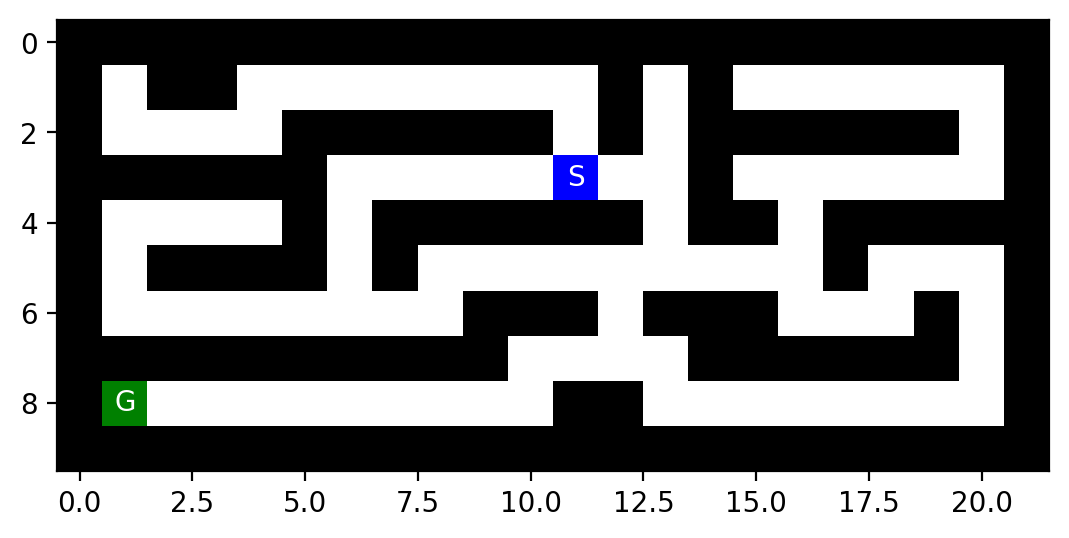

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [6]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [7]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment
    Usage: 
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.
        
        Parameters: 
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.
    
    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one. 
        Caution: there is no error checking!
        
        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)
        
        Returns:
            a tupple (x, y) for the found position.
    
    look(maze, pos)
        Look at the label of a square with the position as an arra

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step. 

In [8]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0
        
        # check if plan is completed
        if self.progress >= len(self.plan):        
            raise Exception("Completed Plan. No more planned actions")
        
        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [9]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['W', 'N', 'W', 'E', 'W', 'S', 'W', 'N', 'E', 'N']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [10]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: S
Following plan... step 1: N
Following plan... step 2: W
Following plan... step 3: W
Following plan... step 4: E
Following plan... step 5: E
Following plan... step 6: E
Following plan... step 7: E
Following plan... step 8: N
Following plan... step 9: W
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python. 
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [11]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [medium maze](medium_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can switch the next block from code to Markdown and use formatting.

**Trạng thái đầu.** $s_0=(r_S,c_S)$ là tọa độ duy nhất chứa ký tự `S`. Một trạng thái chỉ là vị trí `(row, col)` của tác tử; thông tin tìm kiếm không được ghi vào mê cung.

**Tập hành động.** $A=\{N,E,S,W\}$, tương ứng với độ dời $(-1,0),(0,1),(1,0),(0,-1)$. Tại trạng thái $s$, chỉ hành động dẫn tới ô trong biên và khác `X` mới hợp lệ.

**Mô hình chuyển trạng thái.** $Result((r,c),a)=(r+\Delta r_a,c+\Delta c_a)$. Môi trường xác định: cùng trạng thái và hành động luôn cho cùng kết quả.

**Kiểm tra đích.** $Goal(s)$ đúng khi vị trí hiện tại chứa `G`. Phần multiple goals mở rộng điều kiện thành $s\in Goals$.

**Chi phí đường đi.** Mỗi bước hợp lệ có chi phí 1, do đó $g(n)$ bằng số hành động từ `S` tới $n$. Lời giải tối ưu là lời giải có ít bước nhất.

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determine these values for a given maze.

- **$n$ — kích thước không gian trạng thái:** số ô khác `X` có thể đạt được từ `S`. Có thể đếm chính xác bằng một lần duyệt đồ thị từ `S`; luôn có $n\le H\times W$.
- **$d$ — độ sâu lời giải tối ưu:** khoảng cách ngắn nhất từ `S` tới `G`. Vì chi phí mỗi bước bằng 1, BFS cho $d$ chính xác. Khoảng cách Manhattan là cận dưới: $|r_S-r_G|+|c_S-c_G|\le d$.
- **$m$ — độ sâu tối đa:** tree search không kiểm tra lặp có thể đi tới–đi lui nên $m=\infty$. Với đường đi đơn/cycle checking, $m\le n-1$. Bảng thực nghiệm báo thêm độ sâu lớn nhất thực sự được sinh.
- **$b$ — hệ số phân nhánh lớn nhất:** trên lưới bốn hướng, $b\le4$; giá trị thực tế là số láng giềng hợp lệ lớn nhất của một ô.

Các giá trị $n,d,m_{BFS},b$ cụ thể cho tám mê cung được tính tự động trong Task 4 để tránh ước lượng bằng mắt.

## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking. 
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

In [12]:
from collections import deque
from pathlib import Path
import itertools
import heapq
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import maze_helper as mh
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import display, Markdown, HTML

# Cố định thứ tự để mọi lần chạy cho cùng kết quả.
ACTION_ORDER = ('S', 'W', 'E', 'N')
MOVES = {'N': (-1, 0), 'E': (0, 1), 'S': (1, 0), 'W': (0, -1)}
MAZE_FILES = [
    'small_maze.txt', 'medium_maze.txt', 'large_maze.txt',
    'open_maze.txt', 'L_maze.txt', 'loops_maze.txt',
    'empty_maze.txt', 'empty_maze_2.txt',
]

def find_positions(maze, symbol):
    return {tuple(map(int, position)) for position in np.argwhere(maze == symbol)}

def normalize_goals(goal):
    # Chấp nhận một tuple (row, col) hoặc một tập nhiều goal.
    if isinstance(goal, tuple) and len(goal) == 2 and all(np.isscalar(x) for x in goal):
        return {tuple(map(int, goal))}
    return {tuple(map(int, position)) for position in goal}

def legal_successors(maze, state, order=ACTION_ORDER):
    rows, columns = maze.shape
    row, column = state
    for action in order:
        dr, dc = MOVES[action]
        child = (row + dr, column + dc)
        if (0 <= child[0] < rows and 0 <= child[1] < columns
                and maze[child] != 'X'):
            yield action, child

def make_result(algorithm, goal_node, expanded_states, max_depth,
                max_frontier, max_memory, **extra):
    if goal_node is None:
        path, actions, path_cost = None, None, None
    else:
        nodes = goal_node.get_path_from_root()
        path = [node.pos for node in nodes]
        actions = [node.action for node in nodes[1:]]
        path_cost = goal_node.cost
    return {
        'algorithm': algorithm, 'path': path, 'actions': actions,
        'path_cost': path_cost, 'expanded': len(expanded_states),
        'expanded_states': expanded_states, 'max_depth': max_depth,
        'max_frontier': max_frontier, 'max_memory': max_memory,
        **extra,
    }

def breadth_first_search(maze, start, goal):
    goals = normalize_goals(goal)
    root = Node(start, None, None, 0)
    frontier = deque([root])
    reached = {root.pos: root}
    expanded_states = []
    max_depth, max_frontier, max_memory = 0, 1, 1

    while frontier:
        node = frontier.popleft()
        if node.pos in goals:
            return make_result('BFS', node, expanded_states, max_depth,
                               max_frontier, max_memory)

        expanded_states.append(node.pos)
        for action, child_pos in legal_successors(maze, node.pos):
            if child_pos not in reached:
                child = Node(child_pos, node, action, node.cost + 1)
                reached[child_pos] = child
                frontier.append(child)
                max_depth = max(max_depth, child.cost)
        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(reached))

    return make_result('BFS', None, expanded_states, max_depth,
                       max_frontier, max_memory)

def depth_first_search(maze, start, goal):
    """DFS dùng stack frame và ancestor cycle checking, không có reached toàn cục."""
    goals = normalize_goals(goal)
    root = Node(start, None, None, 0)
    stack = [{'node': root, 'successors': None, 'index': 0}]
    on_path = {root.pos}
    expanded_states = []
    max_depth, max_frontier, max_memory = 0, 1, 1

    while stack:
        frame = stack[-1]
        node = frame['node']
        if node.pos in goals:
            return make_result('DFS', node, expanded_states, max_depth,
                               max_frontier, max_memory)

        if frame['successors'] is None:
            expanded_states.append(node.pos)
            frame['successors'] = list(legal_successors(maze, node.pos))

        if frame['index'] >= len(frame['successors']):
            stack.pop()
            on_path.remove(node.pos)
            continue

        action, child_pos = frame['successors'][frame['index']]
        frame['index'] += 1
        if child_pos in on_path:
            continue

        child = Node(child_pos, node, action, node.cost + 1)
        stack.append({'node': child, 'successors': None, 'index': 0})
        on_path.add(child_pos)
        max_depth = max(max_depth, child.cost)
        max_frontier = max(max_frontier, len(stack))
        max_memory = max(max_memory, len(stack))

    return make_result('DFS', None, expanded_states, max_depth,
                       max_frontier, max_memory)

def validate_solution(maze, start, goals, result):
    goals = normalize_goals(goals)
    path = result['path']
    assert path is not None and path[0] == tuple(start) and path[-1] in goals
    assert len(path) - 1 == result['path_cost'] == len(result['actions'])
    for current, nxt in zip(path, path[1:]):
        assert abs(current[0] - nxt[0]) + abs(current[1] - nxt[1]) == 1
        assert maze[nxt] != 'X'
    return True

print('Đã cài đặt BFS và DFS. Thứ tự hành động:', ACTION_ORDER)

Đã cài đặt BFS và DFS. Thứ tự hành động: ('S', 'W', 'E', 'N')


How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

**BFS** dùng `reached`, nên mỗi trạng thái chỉ được đưa vào frontier lần đầu (hoặc theo đường tốt nhất). Vì vậy các cạnh quay lại và chu trình dài đều bị chặn.

**DFS trong bài không dùng `reached` toàn cục.** Nó chỉ giữ `on_path`, tức các trạng thái trên nhánh đang xét. Một trạng thái con trùng với tổ tiên bị loại để tránh vòng lặp; sau khi backtrack, trạng thái được bỏ khỏi `on_path` và có thể xuất hiện lại ở nhánh khác. Cách này giữ bộ nhớ thấp nhưng có thể duyệt lại cùng trạng thái nhiều lần, đặc biệt trong vùng trống có nhiều đường đi đơn. Thứ tự `S, W, E, N` được cố định để kết quả tái lập được; đổi thứ tự có thể làm số nút và đường DFS thay đổi mạnh.

Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

**BFS graph search** đầy đủ trên mê cung hữu hạn và tối ưu vì mọi cạnh có chi phí 1. Theo đồ thị, thời gian là $O(V+E)$ và bộ nhớ $O(V)$; theo mô hình cây tổng quát thường viết thời gian/bộ nhớ $O(b^{d+1})$.

**DFS với ancestor cycle checking** đầy đủ trên đồ thị hữu hạn vì chỉ có hữu hạn đường đi đơn, nhưng không tối ưu: lời giải phụ thuộc thứ tự hành động. Trường hợp xấu có thể phải xét số đường đi đơn tăng theo hàm mũ. Bộ nhớ của triển khai theo stack/frame là $O(bm)$ (các node đang hoạt động chỉ tạo thành một đường sâu $O(m)$), nhỏ hơn nhiều so với frontier rộng của BFS. Đây là đánh đổi chính: DFS tiết kiệm bộ nhớ nhưng thời gian và chất lượng lời giải kém ổn định.

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides). 

In [13]:
def manhattan_distance(state, goals):
    return min(abs(state[0] - goal[0]) + abs(state[1] - goal[1]) for goal in goals)

def informed_search(maze, start, goal, strategy):
    if strategy not in {'GBFS', 'A*'}:
        raise ValueError('strategy phải là GBFS hoặc A*')
    goals = normalize_goals(goal)
    counter = itertools.count()
    root = Node(start, None, None, 0)
    reached = {root.pos: root}
    frontier = []
    expanded_states = []
    max_depth, max_frontier, max_memory = 0, 1, 1

    def priority(node):
        h = manhattan_distance(node.pos, goals)
        return h if strategy == 'GBFS' else node.cost + h

    heapq.heappush(frontier, (priority(root), next(counter), root))
    while frontier:
        _, _, node = heapq.heappop(frontier)
        # Bỏ entry cũ nếu reached đã chứa một đường tốt hơn tới cùng trạng thái.
        if reached.get(node.pos) is not node:
            continue
        if node.pos in goals:
            return make_result(strategy, node, expanded_states, max_depth,
                               max_frontier, max_memory)

        expanded_states.append(node.pos)
        for action, child_pos in legal_successors(maze, node.pos):
            child = Node(child_pos, node, action, node.cost + 1)
            old = reached.get(child_pos)
            if old is None or child.cost < old.cost:
                reached[child_pos] = child
                heapq.heappush(frontier, (priority(child), next(counter), child))
                max_depth = max(max_depth, child.cost)

        max_frontier = max(max_frontier, len(frontier))
        stale = sum(reached.get(entry[2].pos) is not entry[2] for entry in frontier)
        max_memory = max(max_memory, len(reached) + stale)

    return make_result(strategy, None, expanded_states, max_depth,
                       max_frontier, max_memory)

def greedy_best_first_search(maze, start, goal):
    return informed_search(maze, start, goal, 'GBFS')

def a_star_search(maze, start, goal):
    return informed_search(maze, start, goal, 'A*')

print('Đã cài đặt GBFS và A* với Manhattan distance.')

Đã cài đặt GBFS và A* với Manhattan distance.


Are your implementations complete and optimal? What is the time and space complexity?

**GBFS** ưu tiên $h(n)$ và bỏ qua $g(n)$. Với Manhattan, nó thường tiến nhanh về phía đích nhưng không tối ưu; tường có thể khiến hướng trông gần đích trở thành đường vòng. Với không gian hữu hạn và duplicate checking, triển khai này đầy đủ, nhưng thời gian/bộ nhớ trường hợp xấu vẫn $O(b^m)$.

**A-star** ưu tiên $f(n)=g(n)+h(n)$. Manhattan là admissible và consistent cho di chuyển bốn hướng chi phí 1, nên A* graph search đầy đủ và tối ưu. Trường hợp xấu vẫn có thời gian/bộ nhớ hàm mũ, nhưng heuristic thường làm giảm đáng kể số nút mở rộng so với BFS. Cả GBFS và A* phải giữ frontier cùng `reached`, nên yêu cầu bộ nhớ lớn hơn DFS.

## Task 4: Comparison and discussion [20 Points] 

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [14]:
# Đọc tám mê cung mà không thay đổi nội dung file/bản đồ.
maze_candidates = [Path.cwd(), Path.cwd() / 'weekly assignments' / 'lab02 - Searching']
MAZE_DIR = next((path for path in maze_candidates if (path / 'small_maze.txt').exists()), None)
if MAZE_DIR is None:
    raise FileNotFoundError('Không tìm thấy thư mục chứa các file mê cung.')

loaded_mazes = {}
for filename in MAZE_FILES:
    text = (MAZE_DIR / filename).read_text(encoding='utf-8')
    loaded_mazes[filename] = mh.parse_maze(text)

ALGORITHMS = {
    'BFS': breadth_first_search,
    'DFS': depth_first_search,
    'GBFS': greedy_best_first_search,
    'A*': a_star_search,
}

all_results = {}
records = []
for filename, current_maze in loaded_mazes.items():
    start_state = next(iter(find_positions(current_maze, 'S')))
    goals = find_positions(current_maze, 'G')
    all_results[filename] = {}

    for algorithm_name, search_function in ALGORITHMS.items():
        begin = time.perf_counter()
        result = search_function(current_maze, start_state, goals)
        result['runtime_ms'] = (time.perf_counter() - begin) * 1000
        validate_solution(current_maze, start_state, goals, result)
        all_results[filename][algorithm_name] = result
        records.append({
            'maze': filename.replace('_maze', '').replace('.txt', ''),
            'algorithm': algorithm_name,
            'solution': ''.join(result['actions']),
            'path cost': result['path_cost'],
            'nodes expanded': result['expanded'],
            'max tree depth': result['max_depth'],
            'max nodes in memory': result['max_memory'],
            'max frontier': result['max_frontier'],
            'runtime (ms)': result['runtime_ms'],
        })

    # BFS và A* phải thống nhất về chi phí tối ưu.
    assert all_results[filename]['BFS']['path_cost'] == all_results[filename]['A*']['path_cost']

results_df = pd.DataFrame(records)

# Hiển thị một bảng riêng cho từng mê cung theo đúng mẫu của đề.
MAZE_TITLES = {
    'small_maze.txt': 'Small maze',
    'medium_maze.txt': 'Medium maze',
    'large_maze.txt': 'Large maze',
    'open_maze.txt': 'Open maze',
    'L_maze.txt': 'L maze',
    'loops_maze.txt': 'Loops maze',
    'empty_maze.txt': 'Empty maze',
    'empty_maze_2.txt': 'Empty maze 2',
}
TABLE_COLUMNS = {
    'algorithm': 'algorithm',
    'path cost': 'path cost',
    'nodes expanded': '# of nodes expanded',
    'max tree depth': 'max tree depth',
    'max nodes in memory': 'max # of nodes in memory',
    'max frontier': 'max frontier size',
}

for filename in MAZE_FILES:
    maze_key = filename.replace('_maze', '').replace('.txt', '')
    maze_rows = results_df.loc[results_df['maze'] == maze_key].copy()
    maze_table = maze_rows[list(TABLE_COLUMNS)].rename(columns=TABLE_COLUMNS)
    display(Markdown(f"### {MAZE_TITLES[filename]}"))
    display(maze_table.style.hide(axis='index'))

    # Đặt lời giải trong khối thu gọn; mỗi thuật toán một dòng và chuỗi tự xuống dòng.
    solution_rows = []
    for _, row in maze_rows.iterrows():
        sequence = row['solution']
        grouped_sequence = ' '.join(
            sequence[index:index + 10] for index in range(0, len(sequence), 10)
        )
        solution_rows.append(f"""
        <div style="display:grid; grid-template-columns:70px 80px 1fr; gap:10px;
                    align-items:start; padding:8px 0; border-top:1px solid #d1d5db;">
            <strong>{row['algorithm']}</strong>
            <span>{row['path cost']} bước</span>
            <code style="white-space:normal; overflow-wrap:anywhere; line-height:1.65;">
                {grouped_sequence}
            </code>
        </div>
        """)

    solution_panel = f"""
    <details style="margin:10px 0 24px; border:1px solid #9ca3af; border-radius:8px;
                    padding:10px 14px;">
        <summary style="cursor:pointer; font-weight:600;">
            Xem lời giải — chuỗi hành động của 4 thuật toán
        </summary>
        <div style="margin-top:10px;">
            <div style="padding-bottom:8px; color:#6b7280;">
                Quy ước: N = ↑ lên, E = → phải, S = ↓ xuống, W = ← trái.
                Chuỗi được chia thành từng nhóm 10 bước để dễ đọc.
            </div>
            {''.join(solution_rows)}
        </div>
    </details>
    """
    display(HTML(solution_panel))

def graph_profile(maze, start):
    frontier = deque([start])
    distance = {start: 0}
    while frontier:
        state = frontier.popleft()
        for _, child in legal_successors(maze, state):
            if child not in distance:
                distance[child] = distance[state] + 1
                frontier.append(child)
    branching = max(sum(1 for _ in legal_successors(maze, state)) for state in distance)
    return len(distance), max(distance.values()), branching

size_records = []
for filename, current_maze in loaded_mazes.items():
    start_state = next(iter(find_positions(current_maze, 'S')))
    n_states, bfs_depth, branching = graph_profile(current_maze, start_state)
    size_records.append({
        'maze': filename,
        'n': n_states,
        'd': all_results[filename]['BFS']['path_cost'],
        'm_BFS': bfs_depth,
        'm đường đơn ≤': n_states - 1,
        'b': branching,
    })

problem_size_df = pd.DataFrame(size_records)
display(problem_size_df.style.hide(axis='index')
        .set_caption('Kích thước bài toán: n, d, m và b'))
print('✓ Đã chạy và kiểm tra 32 lời giải.')

### Small maze

algorithm,path cost,# of nodes expanded,max tree depth,max # of nodes in memory,max frontier size
BFS,19,91,19,93,8
DFS,29,39,29,30,30
GBFS,29,39,29,44,5
A*,19,53,19,60,8


### Medium maze

algorithm,path cost,# of nodes expanded,max tree depth,max # of nodes in memory,max frontier size
BFS,68,268,68,271,8
DFS,76,76,76,77,77
GBFS,74,78,74,82,4
A*,68,221,68,228,8


### Large maze

...

algorithm,path cost,# of nodes expanded,max tree depth,max # of nodes in memory,max frontier size
BFS,14,95,15,98,11
DFS,88,88,88,89,89
GBFS,14,14,14,43,29
A*,14,63,14,94,31


### Empty maze 2

algorithm,path cost,# of nodes expanded,max tree depth,max # of nodes in memory,max frontier size
BFS,14,95,15,98,12
DFS,18,18,18,19,19
GBFS,14,14,14,43,29
A*,14,63,14,94,31


maze,n,d,m_BFS,m đường đơn ≤,b
small_maze.txt,94,19,20,93,3
medium_maze.txt,274,68,70,273,3
large_maze.txt,647,210,222,646,4
open_maze.txt,684,54,54,683,4
L_maze.txt,157,16,18,156,4
loops_maze.txt,72,23,23,71,4
empty_maze.txt,100,14,16,99,4
empty_maze_2.txt,100,14,16,99,4


✓ Đã chạy và kiểm tra 32 lời giải.


Tám bảng riêng cho tám mê cung được sinh tự động ở cell trên; mỗi bảng gồm bốn thuật toán BFS, DFS, GBFS và A*. Quy ước đo:

- `path cost`: số hành động trong lời giải; cột `solution` chứa chuỗi hành động đầy đủ.
- `nodes expanded`: số node đã lấy ra và sinh successor; node đích không tính là mở rộng.
- `max tree depth`: độ sâu lớn nhất của node đã được sinh.
- `max frontier`: kích thước frontier lớn nhất; với DFS là số frame đang hoạt động.
- `max nodes in memory`: số bản ghi node/trạng thái lớn nhất mà thuật toán giữ.

Mọi đường đi đều được kiểm tra tự động: bắt đầu tại `S`, kết thúc tại `G`, các bước kề nhau và không xuyên tường.

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)). 

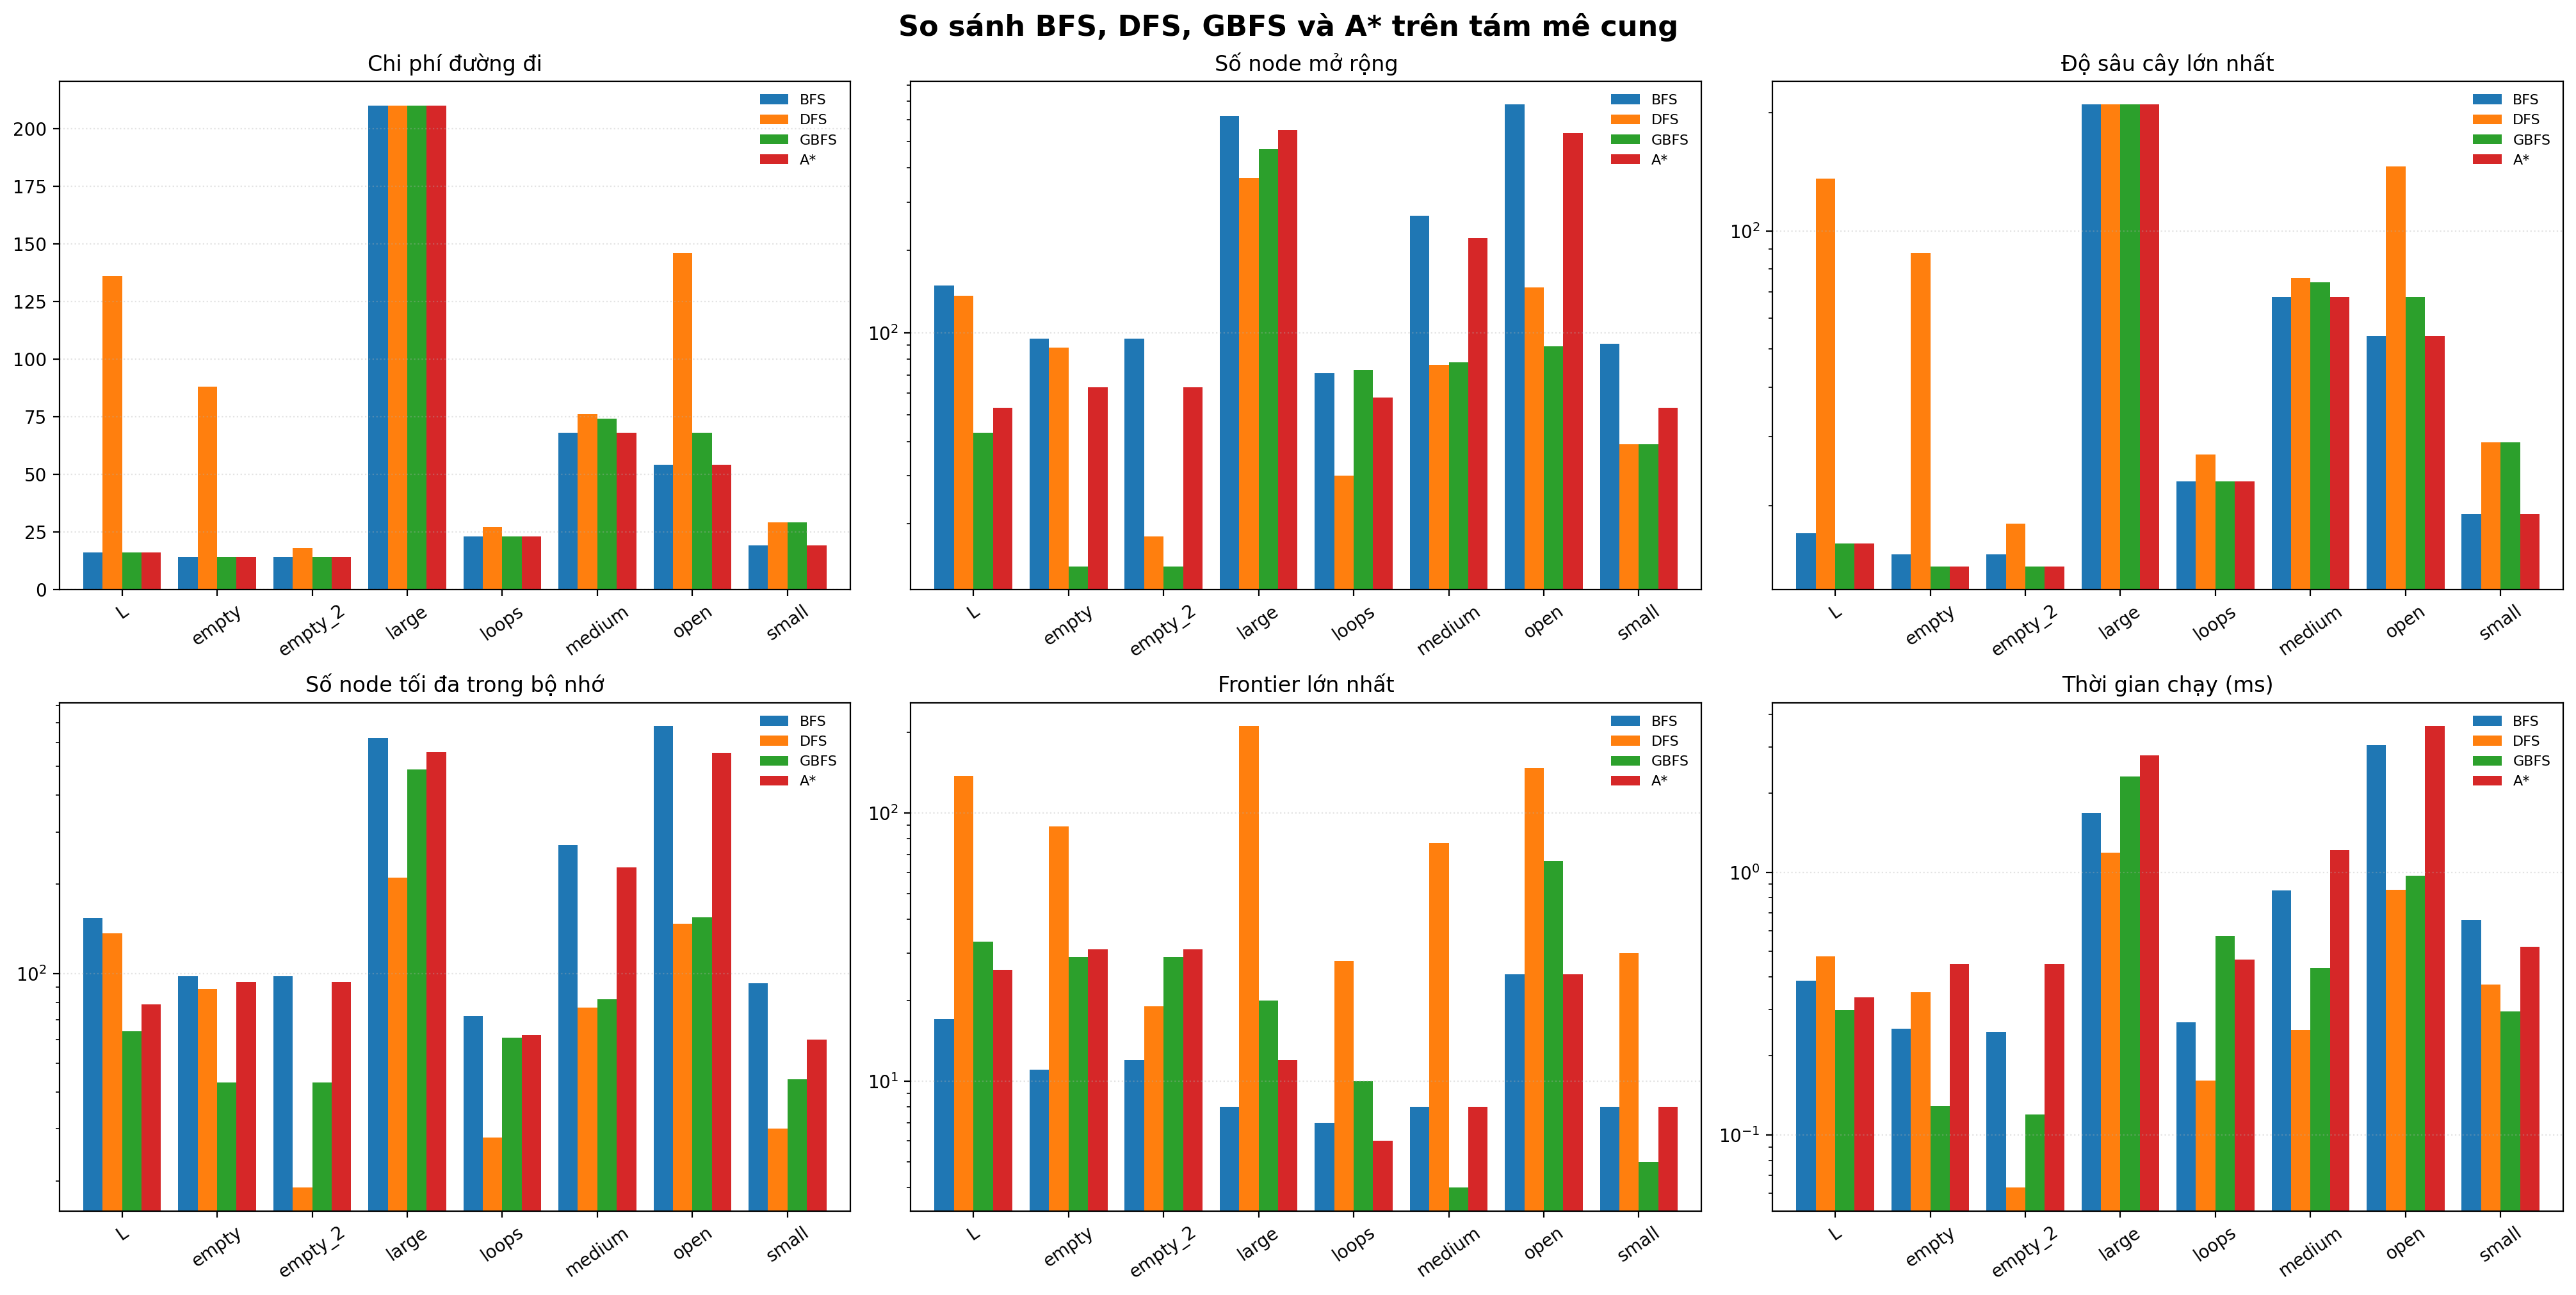

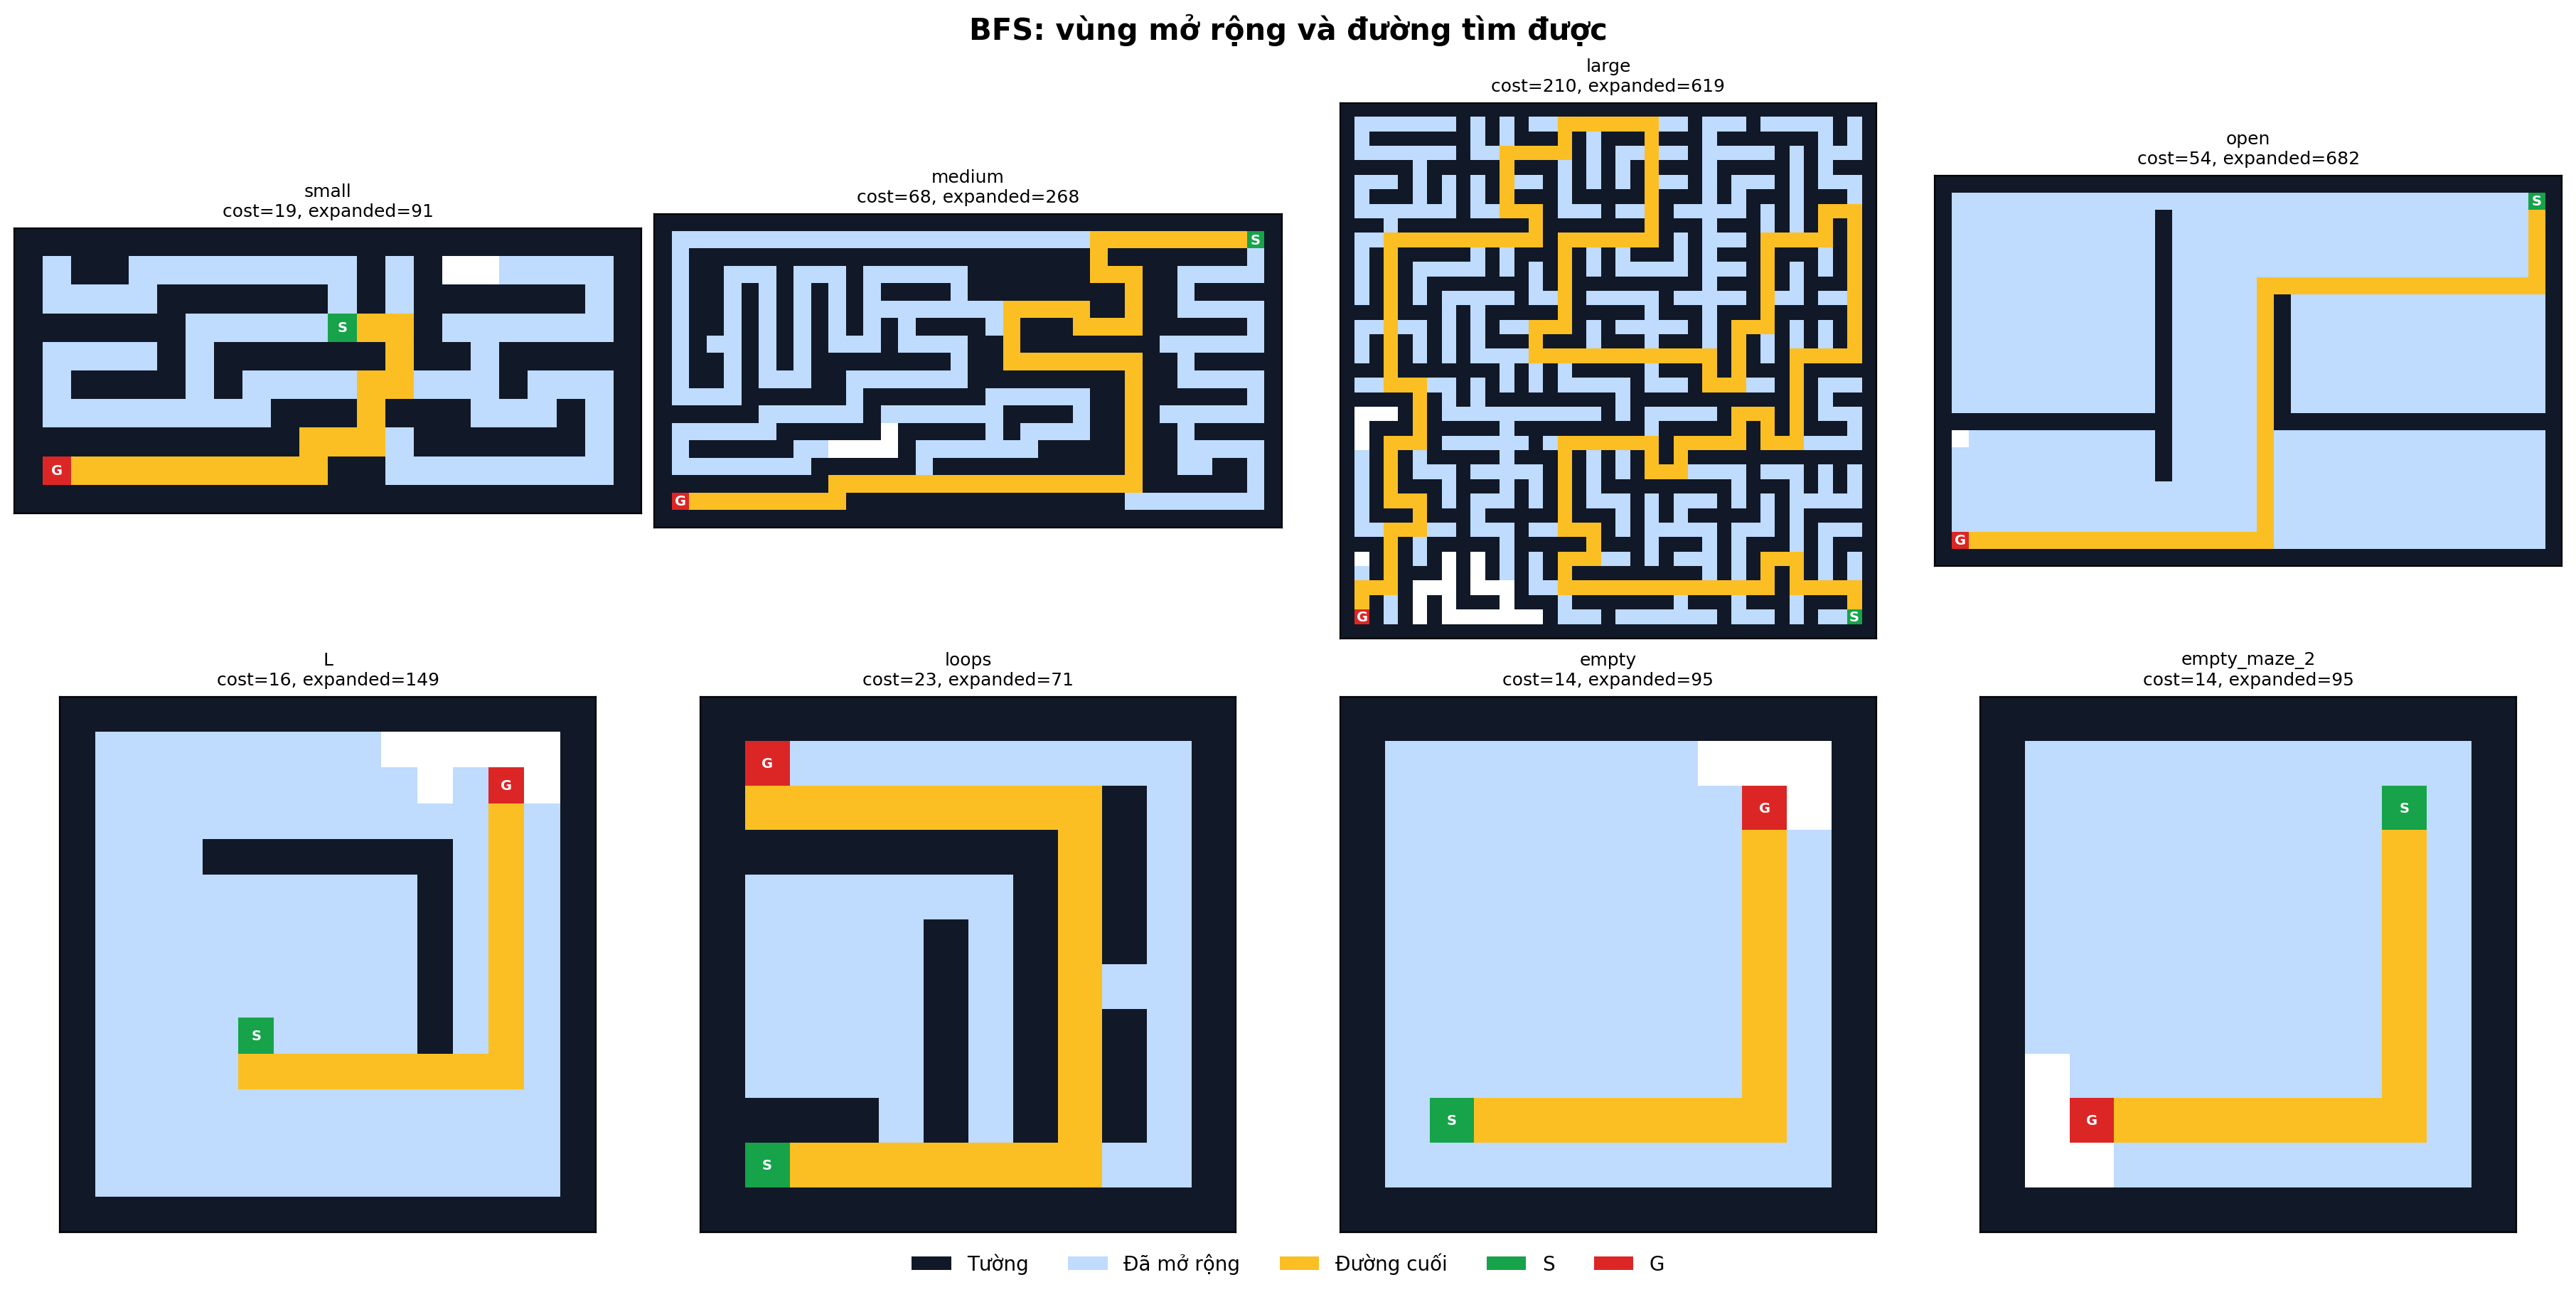

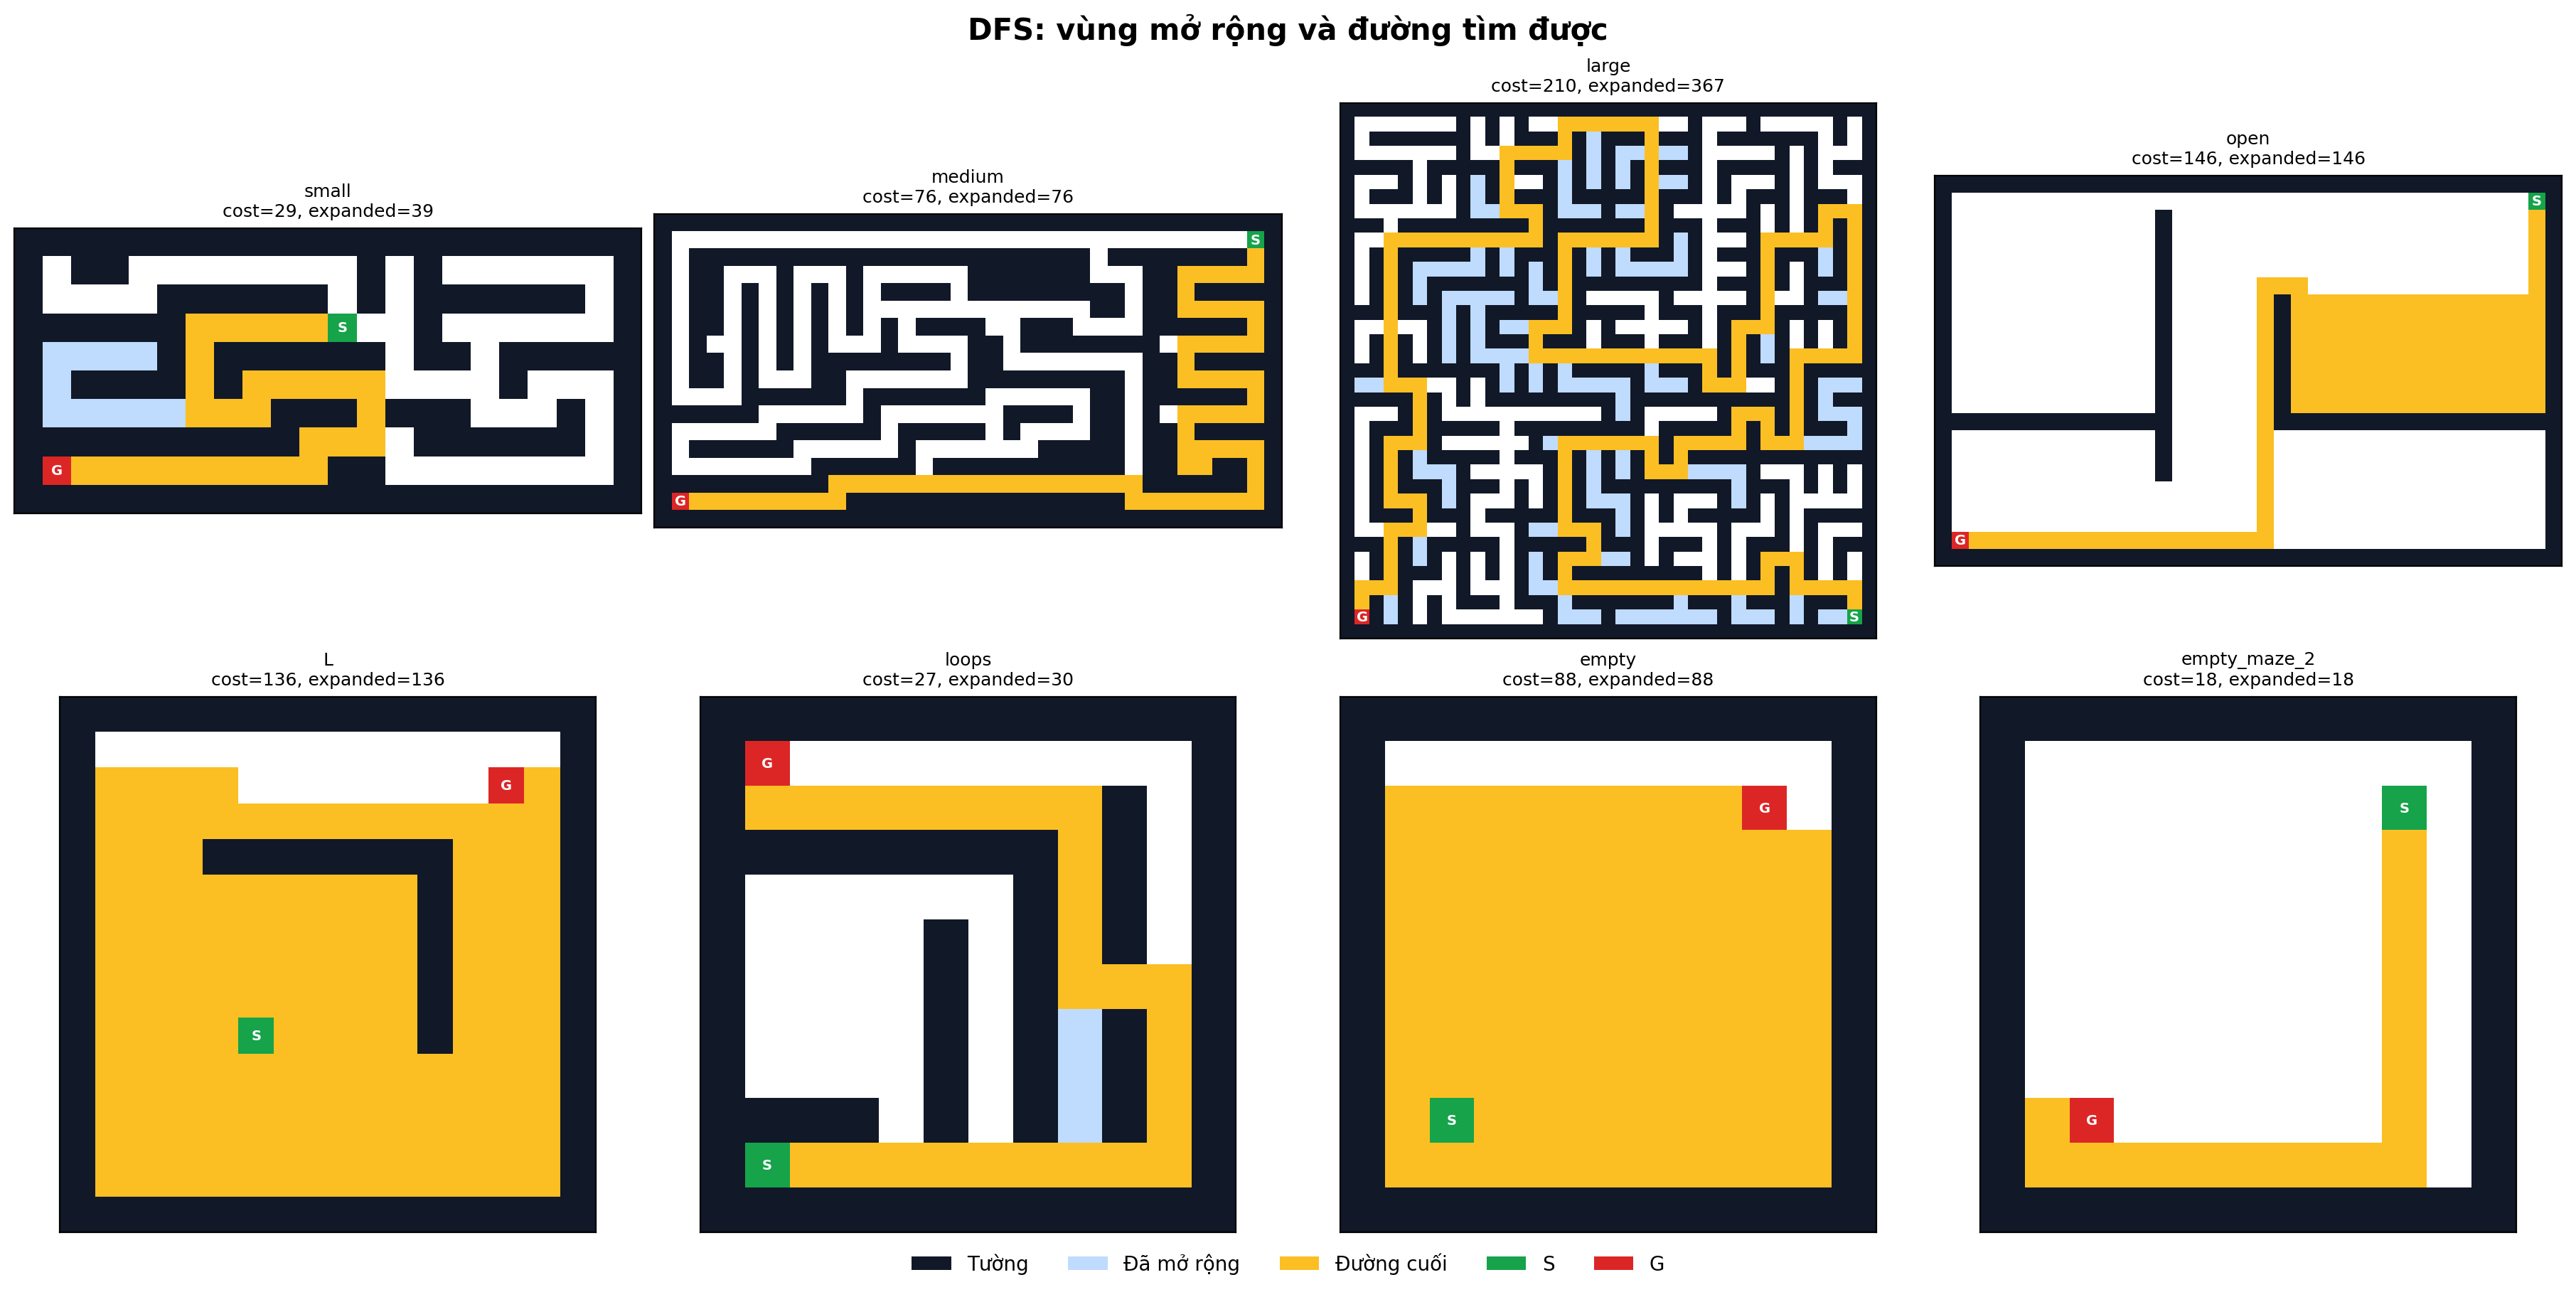

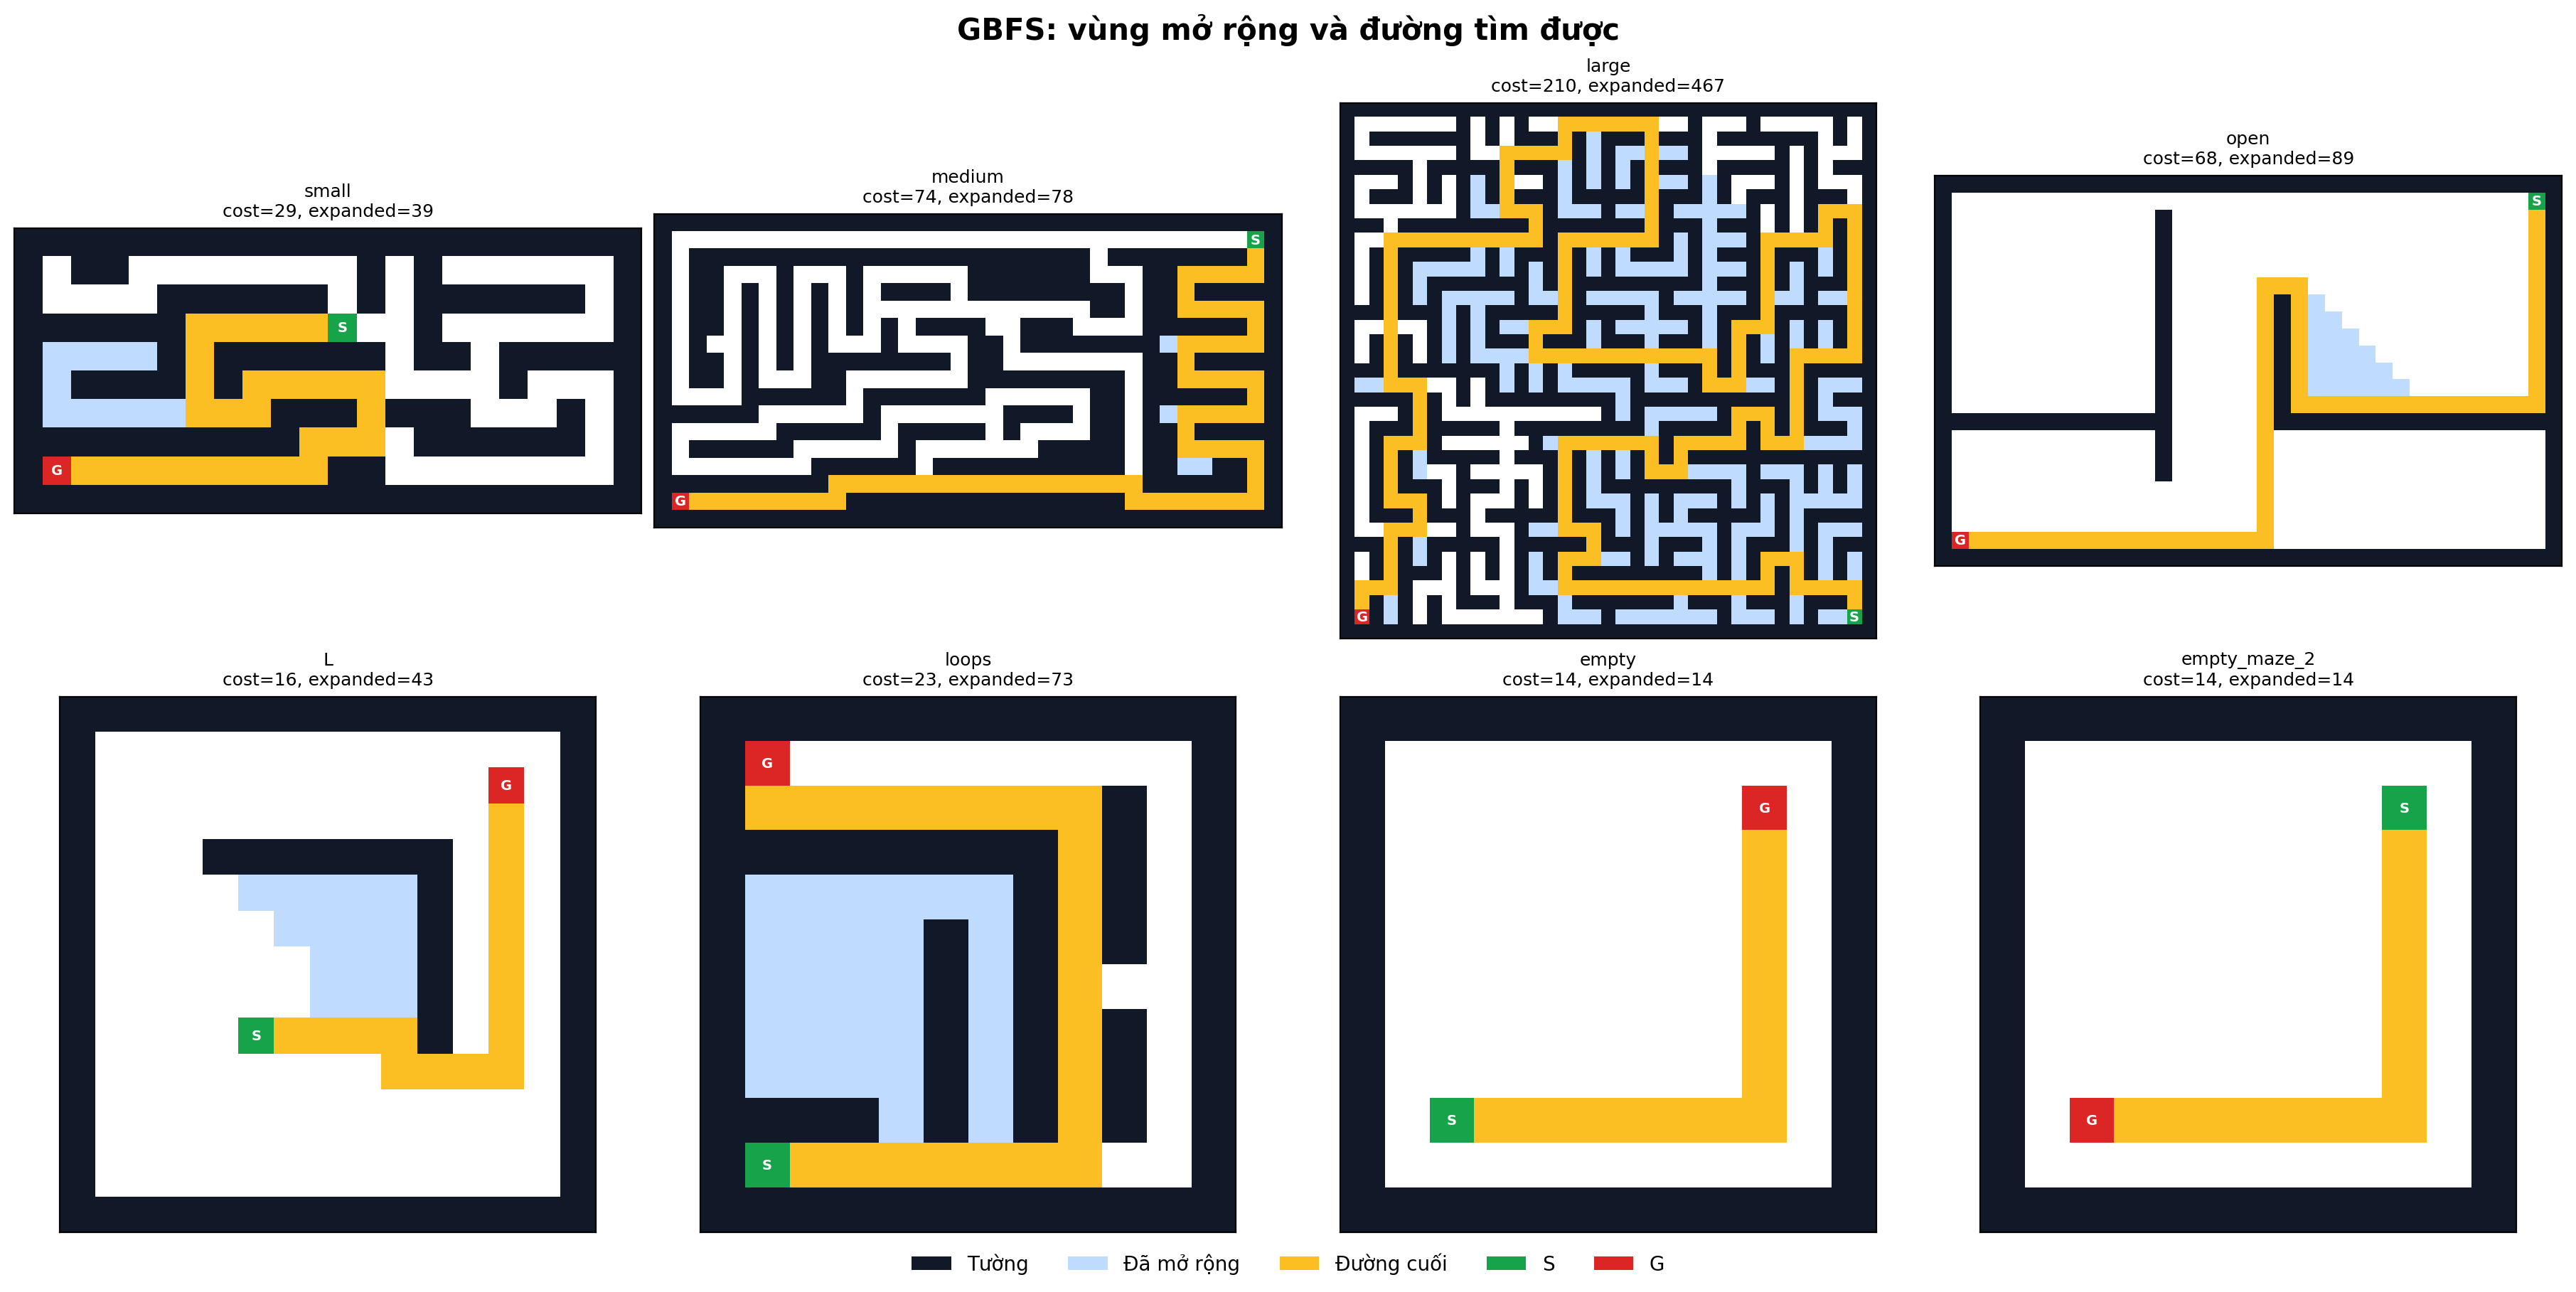

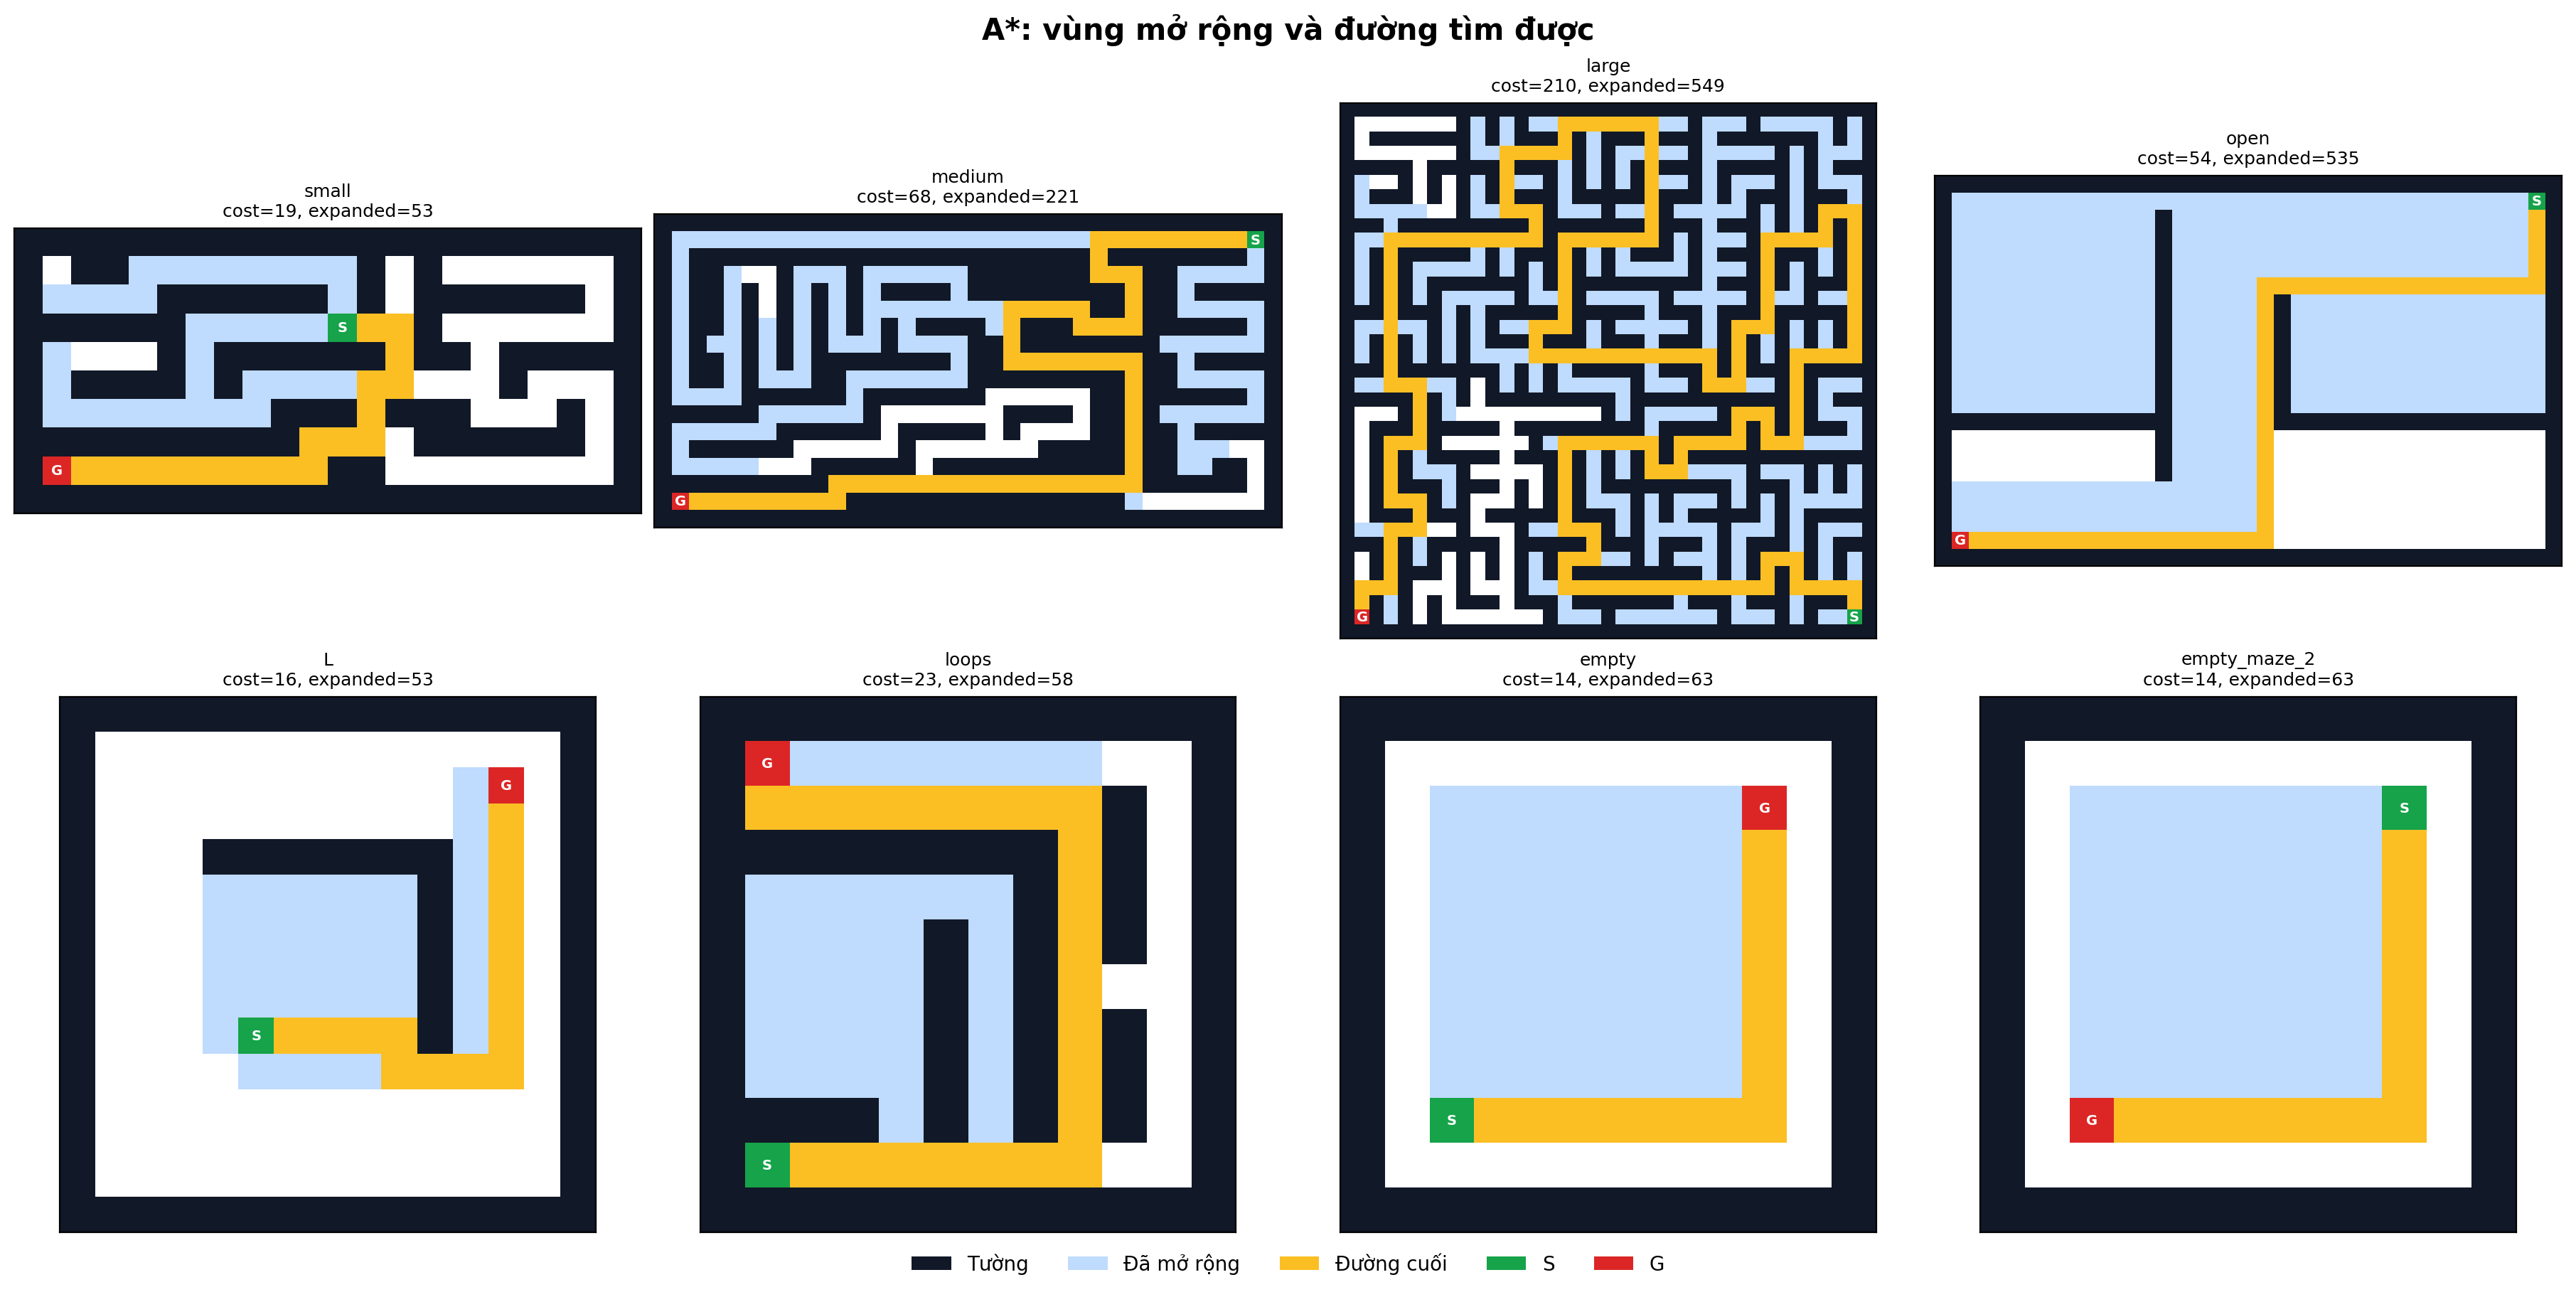

In [15]:
# Biểu đồ định lượng.
metrics = [
    ('path cost', 'Chi phí đường đi', False),
    ('nodes expanded', 'Số node mở rộng', True),
    ('max tree depth', 'Độ sâu cây lớn nhất', True),
    ('max nodes in memory', 'Số node tối đa trong bộ nhớ', True),
    ('max frontier', 'Frontier lớn nhất', True),
    ('runtime (ms)', 'Thời gian chạy (ms)', True),
]
fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
for axis, (column, title, use_log) in zip(axes.flat, metrics):
    pivot = results_df.pivot(index='maze', columns='algorithm', values=column)
    pivot = pivot.reindex(columns=['BFS', 'DFS', 'GBFS', 'A*'])
    pivot.plot(kind='bar', ax=axis, width=0.82)
    axis.set_title(title)
    axis.set_xlabel('')
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='y', linestyle=':', alpha=0.35)
    if use_log and (pivot.to_numpy() > 0).all():
        axis.set_yscale('log')
    axis.legend(frameon=False, fontsize=8)
fig.suptitle('So sánh BFS, DFS, GBFS và A* trên tám mê cung', fontsize=16, fontweight='bold')
plt.show()

# Trực quan hóa: chỉ bản sao dùng để vẽ được đánh dấu; maze gốc không thay đổi.
solution_cmap = ListedColormap([
    '#ffffff', '#111827', '#bfdbfe', '#fbbf24', '#16a34a', '#dc2626'
])
solution_legend = [
    Patch(facecolor='#111827', label='Tường'),
    Patch(facecolor='#bfdbfe', label='Đã mở rộng'),
    Patch(facecolor='#fbbf24', label='Đường cuối'),
    Patch(facecolor='#16a34a', label='S'),
    Patch(facecolor='#dc2626', label='G'),
]

def draw_result(axis, maze, result, title):
    image = np.zeros(maze.shape, dtype=int)
    image[maze == 'X'] = 1
    for state in set(result['expanded_states']):
        if maze[state] == ' ':
            image[state] = 2
    for state in result['path'][1:-1]:
        image[state] = 3
    for state in find_positions(maze, 'S'):
        image[state] = 4
        axis.text(state[1], state[0], 'S', ha='center', va='center',
                  color='white', fontsize=7, fontweight='bold')
    for state in find_positions(maze, 'G'):
        image[state] = 5
        axis.text(state[1], state[0], 'G', ha='center', va='center',
                  color='white', fontsize=7, fontweight='bold')
    axis.imshow(image, cmap=solution_cmap, vmin=0, vmax=5, interpolation='nearest')
    axis.set_title(f"{title}\ncost={result['path_cost']}, expanded={result['expanded']}", fontsize=9)
    axis.set_xticks([])
    axis.set_yticks([])

for algorithm_name in ALGORITHMS:
    fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
    for axis, filename in zip(axes.flat, MAZE_FILES):
        short_name = filename.replace('_maze.txt', '').replace('.txt', '')
        draw_result(axis, loaded_mazes[filename],
                    all_results[filename][algorithm_name], short_name)
    fig.suptitle(f'{algorithm_name}: vùng mở rộng và đường tìm được',
                 fontsize=15, fontweight='bold')
    fig.legend(handles=solution_legend, loc='outside lower center',
               ncol=5, frameon=False)
    plt.show()

Discuss the most important lessons you have learned from implementing the different search strategies. 

1. **Không có thuật toán tốt nhất trong mọi tiêu chí.** BFS ổn định và tối ưu nhưng giữ nhiều trạng thái; DFS dùng ít bộ nhớ nhưng đường đi phụ thuộc mạnh vào thứ tự hành động.
2. **Heuristic thay đổi đáng kể phạm vi tìm kiếm.** GBFS thường mở rộng ít node nhưng có thể trả đường dài; A* kết hợp chi phí đã đi và ước lượng còn lại nên vừa định hướng vừa giữ tối ưu.
3. **Duplicate/cycle checking là một phần của thuật toán, không phải chi tiết phụ.** Dùng `reached` cho BFS/A* ngăn mở rộng lặp; dùng `reached` toàn cục cho DFS/IDS có thể phá đặc tính bộ nhớ hoặc loại nhầm đường trong giới hạn độ sâu.
4. **Cần công bố quy ước đo và tie-breaking.** Các node có cùng priority có thể làm số node mở rộng khác nhau dù chi phí lời giải giống nhau.
5. **Bản đồ chỉ là mô hình chuyển trạng thái.** Dấu đã thăm và đường cuối chỉ được ghi vào bản sao khi vẽ; thuật toán lưu thông tin trong `Node`, frontier và reached đúng theo yêu cầu.

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS 
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [16]:
def depth_limited_search(maze, start, goal, limit):
    """DLS với bảng best_depth được tạo mới cho mỗi vòng IDS."""
    goals = normalize_goals(goal)
    root = Node(start, None, None, 0)
    best_depth = {root.pos: 0}
    expanded_states = []
    cutoff_occurred = False
    max_depth, max_frontier, max_memory = 0, 1, 2

    def visit(node, frames):
        nonlocal cutoff_occurred, max_depth, max_frontier, max_memory
        if node.pos in goals:
            return node

        successors = list(legal_successors(maze, node.pos))
        if node.cost == limit:
            # CUTOFF chỉ khi giới hạn lớn hơn có thể sinh ít nhất một trạng thái mới/tốt hơn.
            if any(node.cost + 1 < best_depth.get(child, np.inf)
                   for _, child in successors):
                cutoff_occurred = True
            return None

        expanded_states.append(node.pos)
        for action, child_pos in successors:
            child_depth = node.cost + 1
            if child_depth < best_depth.get(child_pos, np.inf):
                best_depth[child_pos] = child_depth
                child = Node(child_pos, node, action, child_depth)
                max_depth = max(max_depth, child_depth)
                max_frontier = max(max_frontier, frames + 1)
                max_memory = max(max_memory, len(best_depth) + frames + 1)
                found = visit(child, frames + 1)
                if found is not None:
                    return found
        return None

    goal_node = visit(root, 1)
    status = 'FOUND' if goal_node is not None else ('CUTOFF' if cutoff_occurred else 'FAILURE')
    return make_result('DLS', goal_node, expanded_states, max_depth,
                       max_frontier, max_memory, status=status, limit=limit)

def iterative_deepening_search(maze, start, goal, max_limit=None):
    if max_limit is None:
        max_limit = int(np.count_nonzero(maze != 'X')) - 1
    history = []
    total_expanded = 0
    all_expanded_states = []
    overall_depth = overall_frontier = overall_memory = 0

    for limit in range(max_limit + 1):
        result = depth_limited_search(maze, start, goal, limit)
        total_expanded += result['expanded']
        all_expanded_states.extend(result['expanded_states'])
        overall_depth = max(overall_depth, result['max_depth'])
        overall_frontier = max(overall_frontier, result['max_frontier'])
        overall_memory = max(overall_memory, result['max_memory'])
        history.append({
            'limit': limit, 'status': result['status'],
            'expanded': result['expanded'],
        })

        if result['status'] == 'FOUND':
            result.update({
                'algorithm': 'IDS', 'expanded': total_expanded,
                'expanded_states': all_expanded_states,
                'max_depth': overall_depth, 'max_frontier': overall_frontier,
                'max_memory': overall_memory, 'history': history,
                'iterations': len(history), 'limit_increases': limit,
            })
            return result
        if result['status'] == 'FAILURE':
            break

    return {
        'algorithm': 'IDS', 'path': None, 'actions': None, 'path_cost': None,
        'expanded': total_expanded, 'expanded_states': all_expanded_states,
        'max_depth': overall_depth, 'max_frontier': overall_frontier,
        'max_memory': overall_memory, 'history': history,
        'iterations': len(history), 'limit_increases': max(0, len(history) - 1),
        'status': 'FAILURE',
    }

ids_results = {}
ids_records = []
for filename, current_maze in loaded_mazes.items():
    start_state = next(iter(find_positions(current_maze, 'S')))
    goals = find_positions(current_maze, 'G')
    begin = time.perf_counter()
    result = iterative_deepening_search(current_maze, start_state, goals)
    runtime_ms = (time.perf_counter() - begin) * 1000
    validate_solution(current_maze, start_state, goals, result)
    assert result['path_cost'] == all_results[filename]['BFS']['path_cost']
    ids_results[filename] = result
    ids_records.append({
        'maze': filename, 'path cost': result['path_cost'],
        'found at limit': result['history'][-1]['limit'],
        'DLS calls': result['iterations'],
        'limit increases': result['limit_increases'],
        'nodes expanded (total)': result['expanded'],
        'max frontier': result['max_frontier'],
        'max memory records': result['max_memory'],
        'runtime (ms)': runtime_ms,
    })

ids_df = pd.DataFrame(ids_records)
display(ids_df.style.hide(axis='index').format({'runtime (ms)': '{:.3f}'})
        .set_caption('IDS trên tám mê cung'))
display(Markdown(
    '**Nhận xét.** IDS tìm đúng cùng chi phí tối ưu với BFS. Bảng `best_depth` được '
    'khởi tạo lại ở mỗi giới hạn và chỉ loại đường tới cùng trạng thái nếu không nông hơn. '
    'Cách này xử lý vùng trống hiệu quả hơn ancestor checking thuần túy, nhưng đổi lại bộ nhớ '
    'có thể tăng tới $O(n)$; IDS thuần DFS sẽ dùng ít bộ nhớ hơn nhưng có thể duyệt số lượng '
    'đường đi đơn rất lớn.'
))

maze,path cost,found at limit,DLS calls,limit increases,nodes expanded (total),max frontier,max memory records,runtime (ms)
small_maze.txt,19,19,20,19,850,20,106,4.694
medium_maze.txt,68,68,69,68,11324,69,323,34.540
large_maze.txt,210,210,211,210,60214,211,658,249.585
open_maze.txt,54,54,55,54,123854,55,735,405.499
L_maze.txt,16,16,17,16,3440,17,163,13.088
loops_maze.txt,23,23,24,23,1380,24,93,5.524
empty_maze.txt,14,14,15,14,1424,15,109,7.059
empty_maze_2.txt,14,14,15,14,1290,15,107,6.908


**Nhận xét.** IDS tìm đúng cùng chi phí tối ưu với BFS. Bảng `best_depth` được khởi tạo lại ở mỗi giới hạn và chỉ loại đường tới cùng trạng thái nếu không nông hơn. Cách này xử lý vùng trống hiệu quả hơn ancestor checking thuần túy, nhưng đổi lại bộ nhớ có thể tăng tới $O(n)$; IDS thuần DFS sẽ dùng ít bộ nhớ hơn nhưng có thể duyệt số lượng đường đi đơn rất lớn.

### Multiple Goals 
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

scenario,algorithm,goals,reached goal,path cost,optimal cost,optimal?,nodes expanded
2 goals: thêm G sát S,BFS,"[(1, 33), (16, 1)]","(1, 33)",1,1,Có,2
2 goals: thêm G sát S,DFS,"[(1, 33), (16, 1)]","(16, 1)",76,1,Không,76
2 goals: thêm G sát S,IDS,"[(1, 33), (16, 1)]","(1, 33)",1,1,Có,1
3 goals: thêm G gần và vừa,BFS,"[(1, 30), (7, 33), (16, 1)]","(1, 30)",4,4,Có,8
3 goals: thêm G gần và vừa,DFS,"[(1, 30), (7, 33), (16, 1)]","(7, 33)",15,4,Không,15
3 goals: thêm G gần và vừa,IDS,"[(1, 30), (7, 33), (16, 1)]","(1, 30)",4,4,Có,16


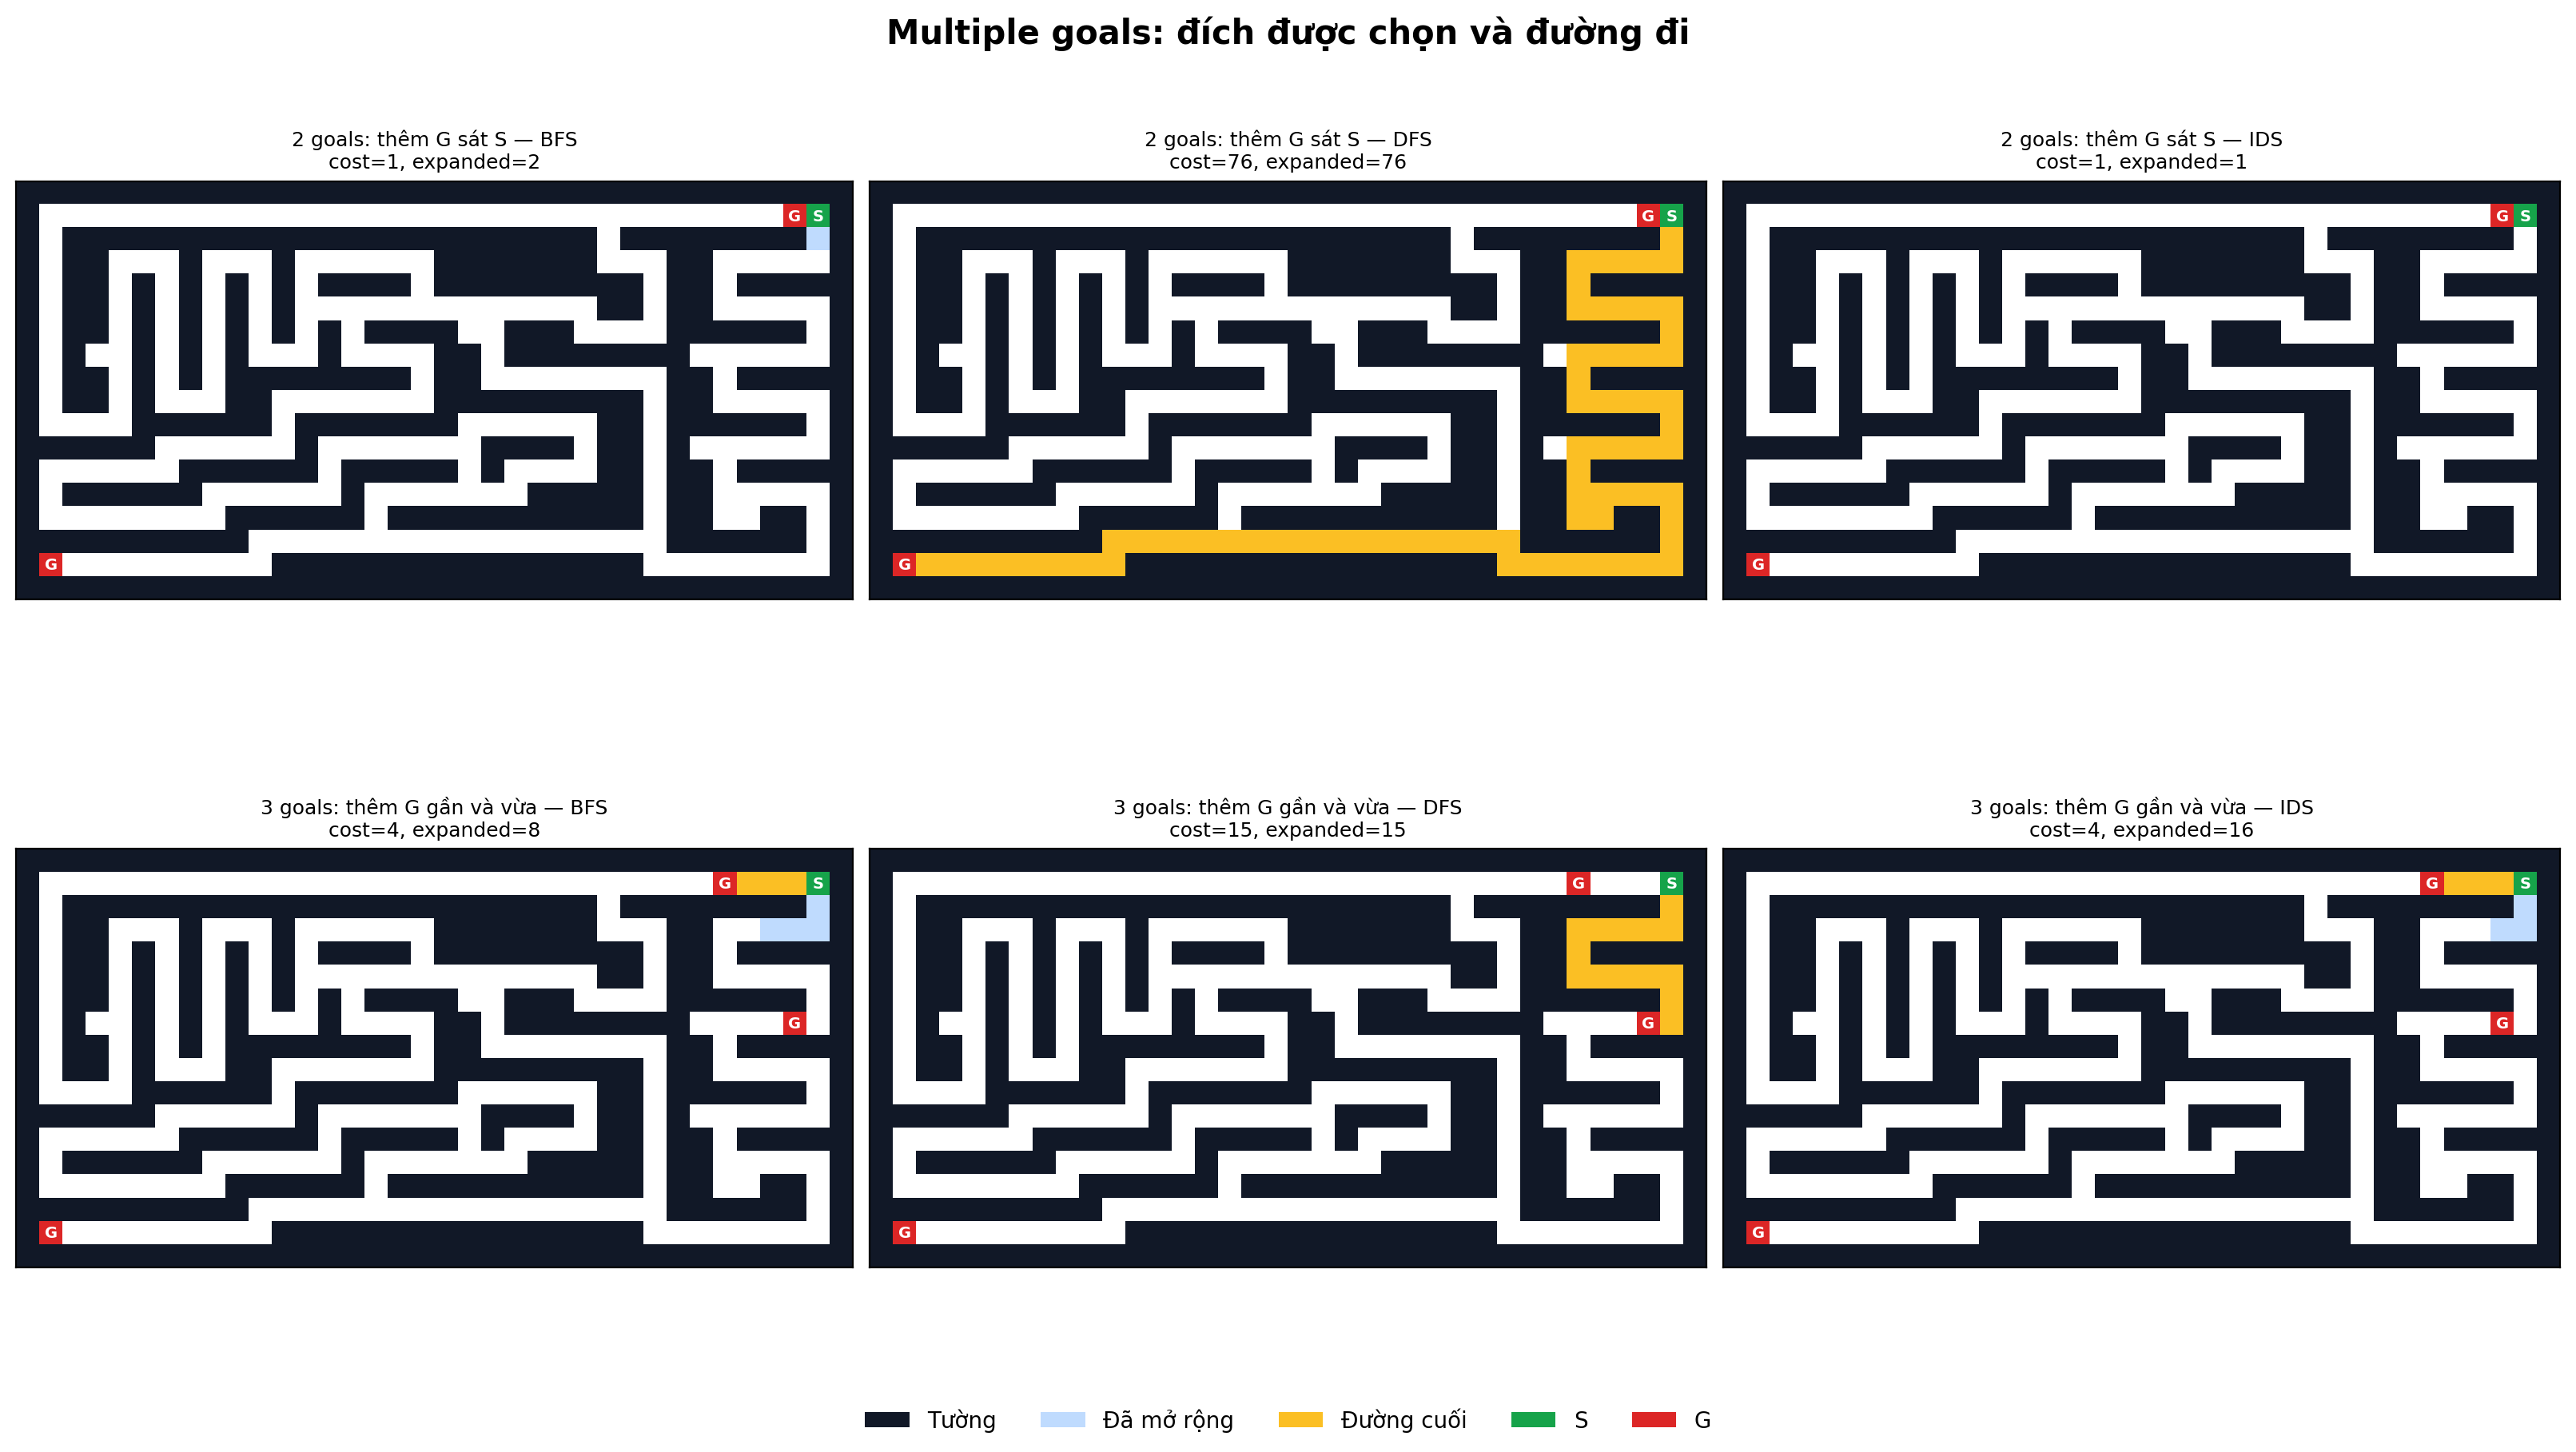

**Kết luận multiple goals.** BFS tìm đích nông nhất theo từng tầng, còn IDS thử toàn bộ giới hạn nhỏ hơn trước, nên cả hai trả chi phí tối ưu khi mỗi bước có chi phí 1. DFS dừng ở đích đầu tiên gặp theo thứ tự `S, W, E, N`; trong hai kịch bản nó lần lượt có thể đi tới một đích xa trước khi xét đích gần hơn. Vì vậy DFS đầy đủ nhưng không tối ưu.

In [17]:
medium_base = loaded_mazes['medium_maze.txt']
multi_goal_specs = {
    '2 goals: thêm G sát S': [(1, 33)],
    '3 goals: thêm G gần và vừa': [(1, 30), (7, 33)],
}
multi_goal_mazes = {}
multi_goal_results = {}
multi_records = []

for scenario, extra_goals in multi_goal_specs.items():
    scenario_maze = medium_base.copy()
    for position in extra_goals:
        assert scenario_maze[position] == ' ', f'{position} không phải ô trống'
        scenario_maze[position] = 'G'
    multi_goal_mazes[scenario] = scenario_maze

    start_state = next(iter(find_positions(scenario_maze, 'S')))
    goals = find_positions(scenario_maze, 'G')
    scenario_results = {
        'BFS': breadth_first_search(scenario_maze, start_state, goals),
        'DFS': depth_first_search(scenario_maze, start_state, goals),
        'IDS': iterative_deepening_search(scenario_maze, start_state, goals),
    }
    optimal_cost = scenario_results['BFS']['path_cost']
    multi_goal_results[scenario] = scenario_results

    for algorithm_name, result in scenario_results.items():
        validate_solution(scenario_maze, start_state, goals, result)
        multi_records.append({
            'scenario': scenario, 'algorithm': algorithm_name,
            'goals': str(sorted(goals)), 'reached goal': str(result['path'][-1]),
            'path cost': result['path_cost'], 'optimal cost': optimal_cost,
            'optimal?': 'Có' if result['path_cost'] == optimal_cost else 'Không',
            'nodes expanded': result['expanded'],
        })

    assert scenario_results['IDS']['path_cost'] == optimal_cost

multi_goal_df = pd.DataFrame(multi_records)
display(multi_goal_df.style.hide(axis='index')
        .set_caption('BFS, DFS và IDS với nhiều đích'))

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for row, (scenario, scenario_maze) in enumerate(multi_goal_mazes.items()):
    for column, algorithm_name in enumerate(('BFS', 'DFS', 'IDS')):
        result = multi_goal_results[scenario][algorithm_name]
        draw_result(axes[row, column], scenario_maze, result,
                    f'{scenario} — {algorithm_name}')
fig.suptitle('Multiple goals: đích được chọn và đường đi', fontsize=15, fontweight='bold')
fig.legend(handles=solution_legend, loc='outside lower center', ncol=5, frameon=False)
plt.show()

display(Markdown(
    '**Kết luận multiple goals.** BFS tìm đích nông nhất theo từng tầng, còn IDS thử '
    'toàn bộ giới hạn nhỏ hơn trước, nên cả hai trả chi phí tối ưu khi mỗi bước có chi phí 1. '
    'DFS dừng ở đích đầu tiên gặp theo thứ tự `S, W, E, N`; trong hai kịch bản nó lần lượt '
    'có thể đi tới một đích xa trước khi xét đích gần hơn. Vì vậy DFS đầy đủ nhưng không tối ưu.'
))

## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [18]:
# Không thực hiện: phần Intersection as States được notebook ghi rõ là không tính điểm.

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [19]:
# Không thực hiện: Weighted A* nằm ngoài phạm vi yêu cầu của Bài 8.

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [20]:
# Không thực hiện: Unknown Maze là câu hỏi mở, không thuộc yêu cầu Bài 8.